In [6]:
import os
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. FEATURE IMPLEMENTATION
# =========================

def energy(signal):
    return np.sum(signal ** 2)

def rms(signal):
    return np.sqrt(np.mean(signal ** 2))

def zcr(signal):
    signs = np.sign(signal)
    signs[signs == 0] = -1
    return np.mean(signs[:-1] != signs[1:])

def extract_features(signal):
    return np.array([
        energy(signal),
        rms(signal),
        zcr(signal)
    ])

# =========================
# 2. LOAD DATA & EXTRACT
# =========================

data_root = r"G:/SP2026/AIL303m/data_merged"
labels = ["speech", "non_speech"]

records = []

for label in labels:
    folder = os.path.join(data_root, label)

    for file in os.listdir(folder):
        if file.lower().endswith(".wav"):
            path = os.path.join(folder, file)

            # Load audio (mono)
            signal, sr = librosa.load(path, sr=None, mono=True)

            feat = extract_features(signal)

            records.append({
                "file": file,
                "label": label,
                "energy": feat[0],
                "rms": feat[1],
                "zcr": feat[2]
            })

df = pd.DataFrame(records)
df.to_csv("features_energy_rms_zcr.csv", index=False)

print(df.head())
print("\nMean features by class:")
print(df.groupby("label")[["energy", "rms", "zcr"]].mean())


               file   label        energy       rms       zcr
0  speech_00001.wav  speech  36138.230469  0.097500  0.127824
1  speech_00002.wav  speech  16404.250000  0.184513  0.090993
2  speech_00003.wav  speech  43575.312500  0.117371  0.085109
3  speech_00004.wav  speech  15224.812500  0.075345  0.220195
4  speech_00005.wav  speech  27901.250000  0.160934  0.131641

Mean features by class:
                  energy       rms       zcr
label                                       
non_speech  38072.596402  0.170125  0.149167
speech      48324.057310  0.133985  0.109558


C:\Users\tdung\AppData\Local\Temp\ipykernel_29576\855946026.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([speech["zcr"], non["zcr"]],


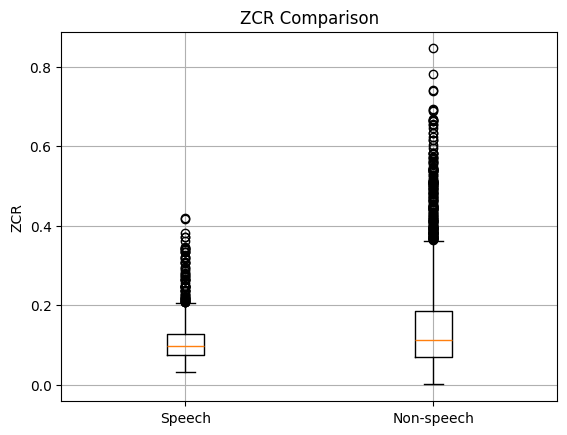

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("features_energy_rms_zcr.csv")

speech = df[df["label"] == "speech"]
non = df[df["label"] == "non_speech"]

# ---- Boxplot ZCR ----
plt.figure()
plt.boxplot([speech["zcr"], non["zcr"]],
            labels=["Speech", "Non-speech"])
plt.ylabel("ZCR")
plt.title("ZCR Comparison")
plt.grid(True)
plt.show()

C:\Users\tdung\AppData\Local\Temp\ipykernel_29576\235637183.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([speech["rms"], non["rms"]],


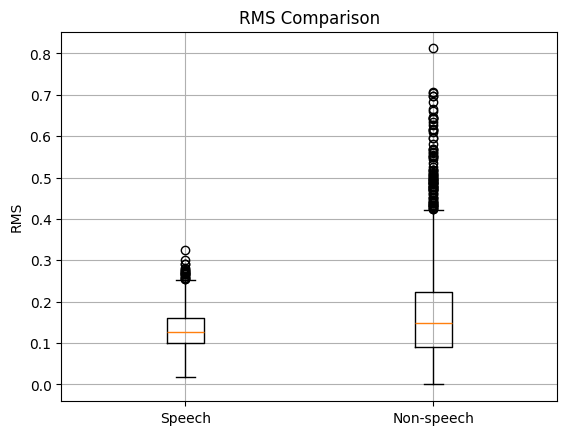

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("features_energy_rms_zcr.csv")


speech = df[df["label"] == "speech"]
non = df[df["label"] == "non_speech"]
plt.figure()
plt.boxplot([speech["rms"], non["rms"]],
            labels=["Speech", "Non-speech"])
plt.ylabel("RMS")
plt.title("RMS Comparison")
plt.grid(True)
plt.show()


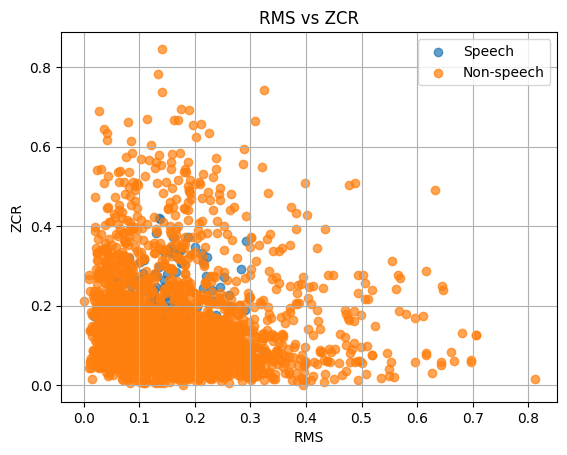

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("features_energy_rms_zcr.csv")

speech = df[df["label"] == "speech"]
non = df[df["label"] == "non_speech"]

plt.figure()
plt.scatter(speech["rms"], speech["zcr"], label="Speech", alpha=0.7)
plt.scatter(non["rms"], non["zcr"], label="Non-speech", alpha=0.7)
plt.xlabel("RMS")
plt.ylabel("ZCR")
plt.title("RMS vs ZCR")
plt.legend()
plt.grid(True)
plt.show()

